**Name:  Anjali Arvind Shirke**    
**Roll No : 07**    
**Assignment 13**   

### Aim
MNIST Handwritten Character Detection using PyTorch, Keras, and TensorFlow.

In [6]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = datasets.MNIST(root='mnist_data', train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)

testset = datasets.MNIST(root='mnist_data', train=False, download=True, transform=transform)
testloader = DataLoader(testset, batch_size=100, shuffle=False)

print(f'Training samples: {len(trainset)}')
print(f'Test samples: {len(testset)}')

Training samples: 60000
Test samples: 10000


In [8]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.fc1 = nn.Linear(1600, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = nn.functional.relu(self.conv1(x))
        x = nn.functional.max_pool2d(x, 2)
        x = nn.functional.relu(self.conv2(x))
        x = nn.functional.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = nn.functional.relu(self.fc1(x))
        x = self.fc2(x)
        return nn.functional.log_softmax(x, dim=1)

pt_model = SimpleCNN()
print(pt_model)

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=1600, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [9]:
criterion = nn.NLLLoss()
optimizer = optim.Adam(pt_model.parameters(), lr=0.001)

pt_epochs = 2
for epoch in range(pt_epochs):
    pt_model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in trainloader:
        optimizer.zero_grad()
        output = pt_model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(output, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(trainloader)
    epoch_acc = correct / total
    print(f'Epoch [{epoch+1}/{pt_epochs}]  Loss: {epoch_loss:.4f}  Accuracy: {epoch_acc:.4f}')

print('\nPyTorch training complete.')

Epoch [1/2]  Loss: 0.1497  Accuracy: 0.9546
Epoch [2/2]  Loss: 0.0444  Accuracy: 0.9862

PyTorch training complete.


In [10]:
pt_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in testloader:
        output = pt_model(images)
        _, predicted = torch.max(output, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

pt_accuracy = correct / total
print(f'PyTorch Test Accuracy: {pt_accuracy:.4f}')

PyTorch Test Accuracy: 0.9860


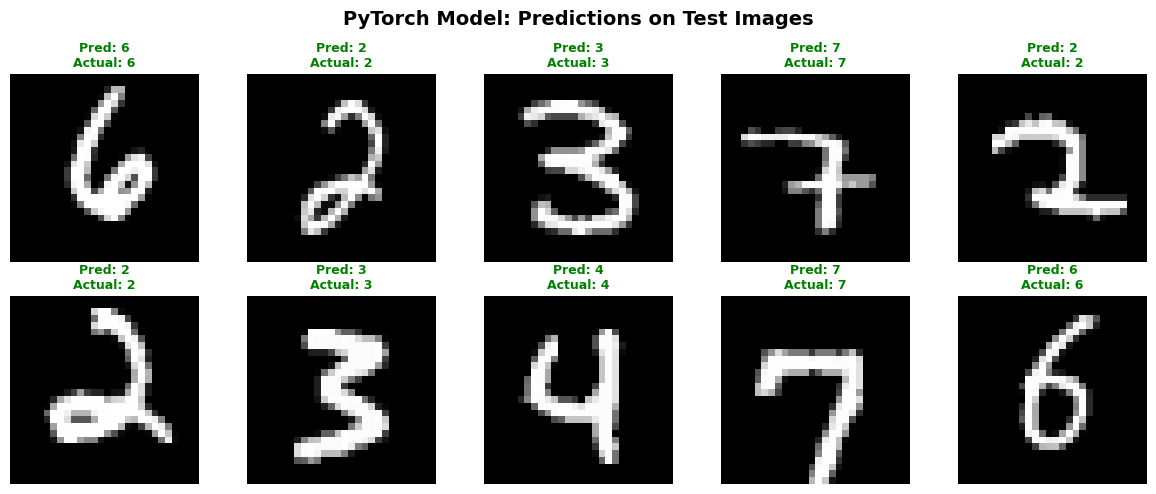

In [12]:
import numpy as np
pt_model.eval()
pt_predictions = []
with torch.no_grad():
    for images, _ in testloader:
        output = pt_model(images)
        _, predicted = torch.max(output, 1)
        pt_predictions.extend(predicted.cpu().numpy())
pt_predictions = np.array(pt_predictions)

import numpy as np
# Use the PyTorch test set images for plotting
x_test_pt = testset.data.numpy()  # shape (10000, 28, 28)
y_test_pt = testset.targets.numpy()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
np.random.seed(42)
indices = np.random.choice(len(x_test_pt), 10, replace=False)
for i, idx in enumerate(indices):
    ax = axes[i // 5, i % 5]
    ax.imshow(x_test_pt[idx], cmap='gray')
    pred = pt_predictions[idx]
    actual = y_test_pt[idx]
    color = 'green' if pred == actual else 'red'
    ax.set_title(f'Pred: {pred}\nActual: {actual}', color=color, fontweight='bold', fontsize=9)
    ax.axis('off')
plt.suptitle('PyTorch Model: Predictions on Test Images', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist as keras_mnist
import numpy as np

In [14]:
(x_train, y_train), (x_test, y_test) = keras_mnist.load_data()

x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

print(f'Training data shape: {x_train.shape}')
print(f'Test data shape: {x_test.shape}')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step 
Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)


In [16]:
k_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

k_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

k_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │         102,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
k_model.fit(x_train, y_train, epochs=2, batch_size=64, validation_split=0.1, verbose=2)

Epoch 1/2
844/844 - 20s - 24ms/step - accuracy: 0.9410 - loss: 0.1943 - val_accuracy: 0.9837 - val_loss: 0.0591
Epoch 2/2
844/844 - 18s - 21ms/step - accuracy: 0.9823 - loss: 0.0561 - val_accuracy: 0.9845 - val_loss: 0.0494


In [18]:
k_loss, k_accuracy = k_model.evaluate(x_test, y_test, verbose=0)
print(f'Keras Test Loss: {k_loss:.4f}')
print(f'Keras Test Accuracy: {k_accuracy:.4f}')

Keras Test Loss: 0.0489
Keras Test Accuracy: 0.9838


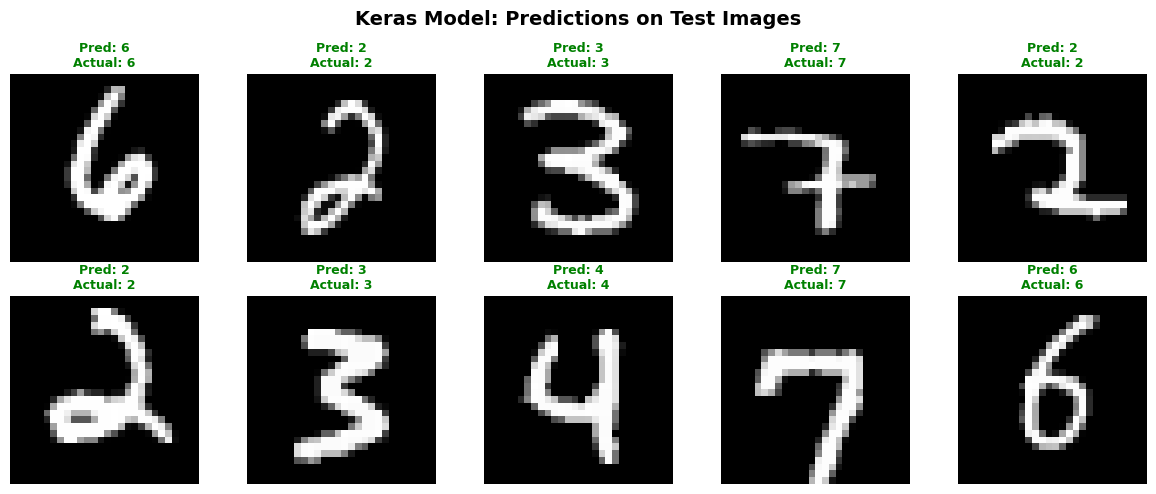

In [19]:
k_predictions = np.argmax(k_model.predict(x_test, verbose=0), axis=1)

x_test_plot = x_test.squeeze()
y_test_plot = y_test.flatten()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
np.random.seed(42)
indices = np.random.choice(len(x_test_plot), 10, replace=False)
for i, idx in enumerate(indices):
    ax = axes[i // 5, i % 5]
    ax.imshow(x_test_plot[idx], cmap='gray')
    pred = k_predictions[idx]
    actual = y_test_plot[idx]
    color = 'green' if pred == actual else 'red'
    ax.set_title(f'Pred: {pred}\nActual: {actual}', color=color, fontweight='bold', fontsize=9)
    ax.axis('off')
plt.suptitle('Keras Model: Predictions on Test Images', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

In [20]:
# Build the same architecture but train with GradientTape
tf_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

tf_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
tf_loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

print('TensorFlow low-level model created.')

TensorFlow low-level model created.


In [21]:
# Create TensorFlow dataset
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(10000).batch(64)

tf_epochs = 2
for epoch in range(tf_epochs):
    epoch_loss = 0.0
    epoch_correct = 0
    epoch_total = 0
    num_batches = 0

    for batch_x, batch_y in train_ds:
        with tf.GradientTape() as tape:
            predictions = tf_model(batch_x, training=True)
            loss = tf_loss_fn(batch_y, predictions)

        # Compute and apply gradients
        gradients = tape.gradient(loss, tf_model.trainable_variables)
        tf_optimizer.apply_gradients(zip(gradients, tf_model.trainable_variables))

        epoch_loss += loss.numpy()
        predicted_labels = tf.argmax(predictions, axis=1)
        epoch_correct += tf.reduce_sum(tf.cast(predicted_labels == tf.cast(batch_y, tf.int64), tf.int32)).numpy()
        epoch_total += len(batch_y)
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    accuracy = epoch_correct / epoch_total
    print(f'Epoch [{epoch+1}/{tf_epochs}]  Loss: {avg_loss:.4f}  Accuracy: {accuracy:.4f}')

print('\nTensorFlow (GradientTape) training complete.')

Epoch [1/2]  Loss: 0.1726  Accuracy: 0.9483
Epoch [2/2]  Loss: 0.0521  Accuracy: 0.9843

TensorFlow (GradientTape) training complete.


In [22]:
test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(100)

tf_correct = 0
tf_total = 0
for batch_x, batch_y in test_ds:
    predictions = tf_model(batch_x, training=False)
    predicted_labels = tf.argmax(predictions, axis=1)
    tf_correct += tf.reduce_sum(tf.cast(predicted_labels == tf.cast(batch_y, tf.int64), tf.int32)).numpy()
    tf_total += len(batch_y)

tf_accuracy = tf_correct / tf_total
print(f'TensorFlow (GradientTape) Test Accuracy: {tf_accuracy:.4f}')

TensorFlow (GradientTape) Test Accuracy: 0.9862


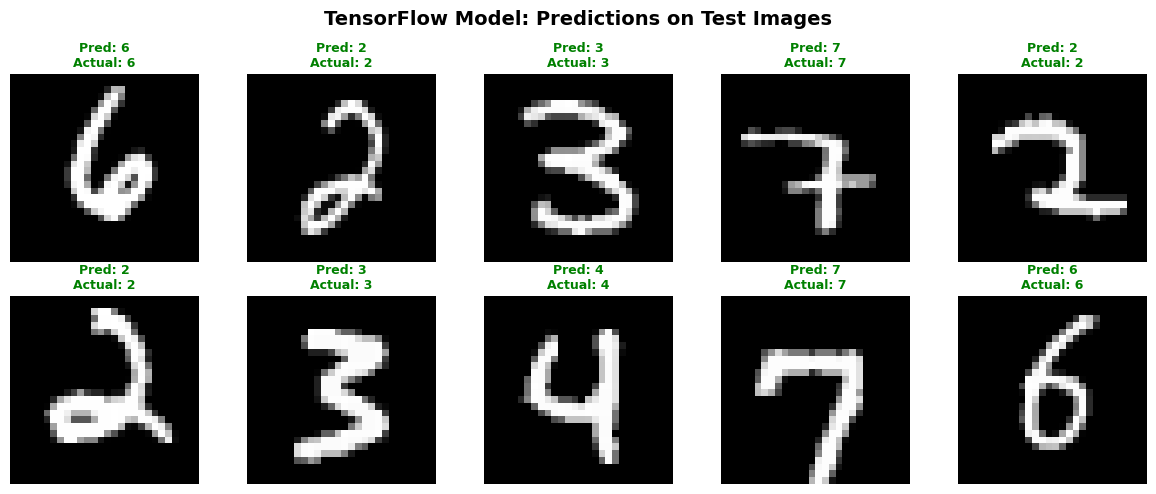

In [23]:
tf_predictions = np.argmax(tf_model(x_test, training=False), axis=1)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
np.random.seed(42)
indices = np.random.choice(len(x_test), 10, replace=False)
for i, idx in enumerate(indices):
    ax = axes[i // 5, i % 5]
    ax.imshow(x_test[idx].squeeze(), cmap='gray')
    pred = tf_predictions[idx]
    actual = y_test[idx]
    color = 'green' if pred == actual else 'red'
    ax.set_title(f'Pred: {pred}\nActual: {actual}', color=color, fontweight='bold', fontsize=9)
    ax.axis('off')
plt.suptitle('TensorFlow Model: Predictions on Test Images', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

In [24]:
print('=' * 50)
print('Framework Comparison on MNIST')
print('=' * 50)
print(f'PyTorch              Test Accuracy: {pt_accuracy:.4f}')
print(f'Keras                Test Accuracy: {k_accuracy:.4f}')
print(f'TensorFlow (manual)  Test Accuracy: {tf_accuracy:.4f}')
print('=' * 50)

Framework Comparison on MNIST
PyTorch              Test Accuracy: 0.9860
Keras                Test Accuracy: 0.9838
TensorFlow (manual)  Test Accuracy: 0.9862
